# Phishing URL Detector
Trains a classifier on URL-based features to detect phishing sites.

**Pipeline:**
1. Load & clean two datasets (phishing_site_urls.csv + dataset_phishing.csv)
2. Extract 22 URL features via `feature_extract.py`
3. Train/test split → SMOTE → StandardScaler
4. Compare four models, optimising for **phishing recall ≥ 0.75**
5. Select best model and save threshold
6. Save model to `phishing_model.pkl`


## 1. Imports

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from feature_extract import extract_features, FEATURE_NAMES

## 2. Load & Merge Datasets

Two datasets are combined:
- **phishing_site_urls.csv** — 156K phishing URLs used (legitimate class discarded due to data quality issues)
- **dataset_phishing.csv** — 11K clean balanced URLs with real legitimate examples


In [2]:
# ── Dataset 1: phishing_site_urls.csv ──────────────────────────────────────
# This dataset has 156K phishing URLs (bad) and 392K 'good' URLs.
# The 'good' class contains corrupted/malformed URLs — NOT real legitimate sites.
# We use ONLY the phishing URLs (bad=1) from this dataset.
df1 = pd.read_csv("phishing_site_urls.csv")
df1 = df1.rename(columns={"URL": "url", "Label": "label"})
df1["label"] = df1["label"].map({"bad": 1, "good": 0})
df1 = df1[df1["label"] == 1][["url", "label"]]  # phishing URLs only
print(f"df1 (phishing only): {df1.shape}")

# ── Dataset 2: dataset_phishing.csv ─────────────────────────────────────────
# Clean, balanced dataset with real legitimate URLs and real phishing URLs.
# 5,715 legitimate + 5,715 phishing — properly labelled.
df2 = pd.read_csv("dataset_phishing.csv")[["url", "status"]]
df2["label"] = df2["status"].map({"phishing": 1, "legitimate": 0})
df2 = df2[["url", "label"]]
print(f"df2 (balanced): {df2.shape}")

# ── Merge ────────────────────────────────────────────────────────────────────
df = (
    pd.concat([df1, df2], ignore_index=True)
    .drop_duplicates(subset="url")
    .dropna(subset=["label"])
    .reset_index(drop=True)
)

# Filter malformed URLs
df = df[df["url"].str.len() > 10]
df = df[df["url"].str.contains(r"\.", regex=True)]

print(f"\nFinal dataset shape: {df.shape}")
print(df["label"].value_counts())


df1 (phishing only): (156422, 2)
df2 (balanced): (11430, 2)

Final dataset shape: (125404, 2)
label
1    119689
0      5715
Name: count, dtype: int64


## 3. Feature Extraction

Features are extracted via `feature_extract.py` — imported above.
This keeps training and inference in sync automatically.

In [3]:
feature_matrix = df["url"].apply(extract_features).tolist()
X = pd.DataFrame(feature_matrix, columns=FEATURE_NAMES)
y = df["label"]

print(X.shape)
X.head()

(125404, 22)


,suspicious_words,dots,hyphens,path_len,domain_digits,domain_len,domain_entropy,num_params,is_shortened,has_ip,...,subdomains,https,prefix_suffix,redirect,abnormal_www,double_slash,special_chars,suspicious_tld,brand,free_ddns
0,1,6,4,134,0,9,2.947703,4,0,0,...,1,0,0,0,0,0,17,0,0,0
1,0,5,2,81,0,15,3.189898,2,0,0,...,2,0,0,0,1,0,9,0,1,0
2,1,7,1,60,0,16,3.327820,0,0,0,...,1,0,0,0,0,0,8,0,1,0
3,0,6,0,60,0,18,3.572431,0,0,0,...,2,0,0,0,1,0,6,0,0,0
4,0,1,1,60,0,19,3.787144,1,0,0,...,1,0,0,0,0,0,7,0,0,0


## 4. Train / Test Split → SMOTE → Scaling

**Important ordering:** split first, then SMOTE only on the training set.
Doing SMOTE before splitting leaks synthetic samples into the test set.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Oversample minority class in training data only
X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Scale — fit on training data only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Train: (191502, 22), Test: (25081, 22)
Train class balance: {0: 95751, 1: 95751}


## 5. Model Comparison

Four models compared: Logistic Regression, Random Forest, Gradient Boosting, XGBoost.

Threshold is tuned per model to achieve **phishing recall ≥ 0.75** (catch at least 75% of phishing URLs).
Among models that meet this target, the one with the highest phishing F1 is selected.

For a security tool, missing a phishing URL is more dangerous than a false alarm — recall is prioritised.

In [5]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=25, min_samples_split=5,
        min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=600, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=ratio * 2,
        min_child_weight=3, gamma=0.05, reg_alpha=0.1, reg_lambda=1.5,
        random_state=42, eval_metric="logloss", n_jobs=-1,
    ),
}

TARGET_RECALL = 0.75
results = {}

for name, clf in candidates.items():
    print("Training", name)
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.01, 0.99, 200)
    best_t, best_f1 = 0.5, 0.0
    for t in sorted(thresholds, reverse=True):
        y_pred_t = (y_prob > t).astype(int)
        rec = recall_score(y_test, y_pred_t, pos_label=1)
        if rec >= TARGET_RECALL:
            f1 = f1_score(y_test, y_pred_t, pos_label=1)
            best_t, best_f1 = t, f1
            break

    y_pred = (y_prob > best_t).astype(int)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    results[name] = {"clf": clf, "threshold": best_t, "recall": rec, "f1": best_f1, "acc": acc}
    print("  threshold=%.3f | recall=%.3f | f1=%.3f | acc=%.4f" % (best_t, rec, best_f1, acc))
    print(classification_report(y_test, y_pred))

eligible = {k: v for k, v in results.items() if v["recall"] >= TARGET_RECALL}
best_model_name = max(eligible or results, key=lambda k: (eligible or results)[k]["f1"])
print("Best model:", best_model_name)


Training Logistic Regression
  threshold=0.660 | recall=0.754 | f1=0.858 | acc=0.7618
              precision    recall  f1-score   support

           0       0.15      0.91      0.26      1143
           1       0.99      0.75      0.86     23938

    accuracy                           0.76     25081
   macro avg       0.57      0.83      0.56     25081
weighted avg       0.96      0.76      0.83     25081

Training Random Forest
  threshold=0.911 | recall=0.752 | f1=0.857 | acc=0.7615
              precision    recall  f1-score   support

           0       0.16      0.97      0.27      1143
           1       1.00      0.75      0.86     23938

    accuracy                           0.76     25081
   macro avg       0.58      0.86      0.56     25081
weighted avg       0.96      0.76      0.83     25081

Training Gradient Boosting
  threshold=0.862 | recall=0.754 | f1=0.859 | acc=0.7632
              precision    recall  f1-score   support

           0       0.16      0.97      0.

## 6. Final Model — Threshold Tuning via ROC / Youden's J

Youden's J (TPR − FPR) gives a principled threshold that balances
sensitivity and specificity, rather than just maximising F1 on one split.

Best threshold: 0.9605
ROC AUC: 0.9665


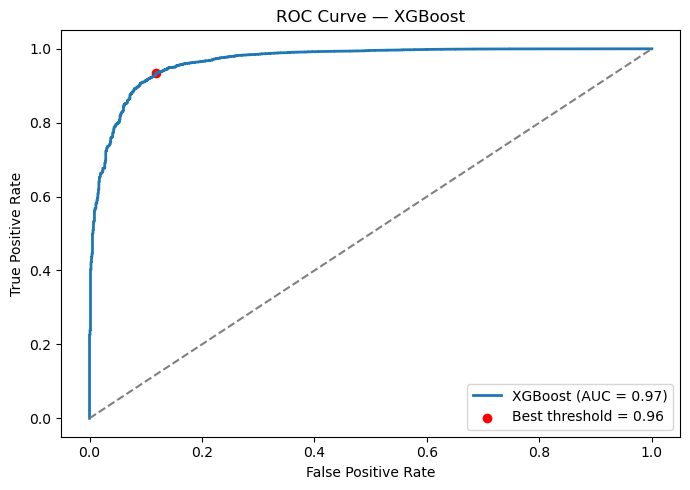

In [6]:
best       = results[best_model_name]
final_model  = best["clf"]
best_threshold = best["threshold"]
y_prob = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
best_roc_idx = (tpr - fpr).argmax()

print(f"Best threshold: {best_threshold:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f"{best_model_name} (AUC = {roc_auc:.2f})")
plt.scatter(fpr[best_roc_idx], tpr[best_roc_idx], marker="o", color="red",
            label=f"Best threshold = {best_threshold:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
y_pred = (y_prob > best_threshold).astype(int)
print(f"Final accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Final accuracy : 0.7705
              precision    recall  f1-score   support

           0       0.16      0.96      0.28      1143
           1       1.00      0.76      0.86     23938

    accuracy                           0.77     25081
   macro avg       0.58      0.86      0.57     25081
weighted avg       0.96      0.77      0.84     25081



## 7. Feature Importance

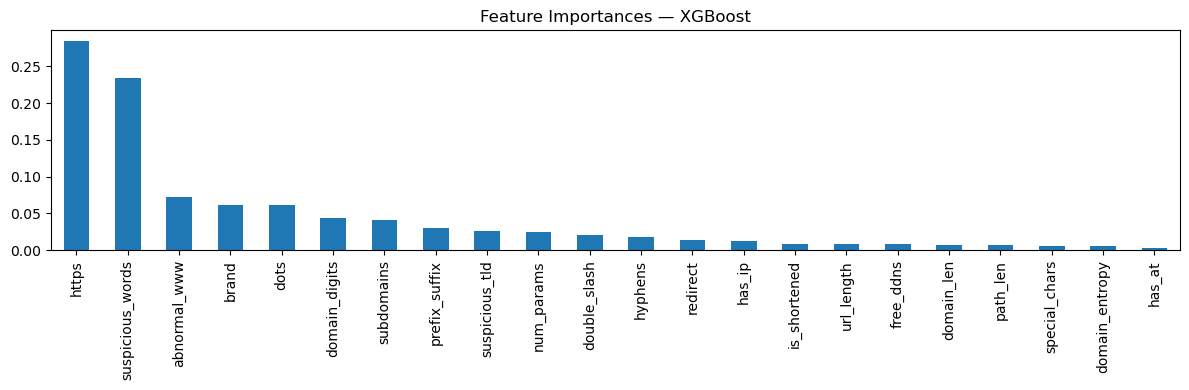

https               0.284476
suspicious_words    0.233317
abnormal_www        0.071843
brand               0.061601
dots                0.061479
domain_digits       0.044221
subdomains          0.041355
prefix_suffix       0.030153
suspicious_tld      0.025907
num_params          0.025010
double_slash        0.021110
hyphens             0.017734
redirect            0.013379
has_ip              0.013072
is_shortened        0.008670
url_length          0.008207
free_ddns           0.008105
domain_len          0.007547
path_len            0.006562
special_chars       0.006297
domain_entropy      0.006242
has_at              0.003712
dtype: float32


In [8]:
importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_NAMES
).sort_values(ascending=False)

importance.plot(kind="bar", figsize=(12, 4), title=f"Feature Importances — {best_model_name}")
plt.tight_layout()
plt.show()
print(importance)

## 8. Save Model

In [9]:
model_data = {
    "model":     final_model,
    "scaler":    scaler,
    "threshold": best_threshold,
    "features":  FEATURE_NAMES,
}

with open("phishing_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print(f"Saved -> phishing_model.pkl")
print(f"Model: {best_model_name}")
print(f"Threshold: {best_threshold:.4f}")

Saved -> phishing_model.pkl
Model: XGBoost
Threshold: 0.9605


In [10]:
import pickle
with open("phishing_model.pkl", "rb") as f:
    saved = pickle.load(f)

print("Features model was trained on:", len(saved["features"]))
print(saved["features"])

Features model was trained on: 22
['suspicious_words', 'dots', 'hyphens', 'path_len', 'domain_digits', 'domain_len', 'domain_entropy', 'num_params', 'is_shortened', 'has_ip', 'has_at', 'url_length', 'subdomains', 'https', 'prefix_suffix', 'redirect', 'abnormal_www', 'double_slash', 'special_chars', 'suspicious_tld', 'brand', 'free_ddns']


In [11]:
import sys
sys.path.insert(0, '.')
from feature_extract import FEATURE_NAMES
print(len(FEATURE_NAMES))
print(FEATURE_NAMES)

22
['suspicious_words', 'dots', 'hyphens', 'path_len', 'domain_digits', 'domain_len', 'domain_entropy', 'num_params', 'is_shortened', 'has_ip', 'has_at', 'url_length', 'subdomains', 'https', 'prefix_suffix', 'redirect', 'abnormal_www', 'double_slash', 'special_chars', 'suspicious_tld', 'brand', 'free_ddns']
